# 2 — BLIP 이미지 캡셔닝

이 Notebook은 CLIP·BLIP 24시간 교육과정의 실습 자료이다. 코드를 위에서부터 순서대로 실행한다.

## 1. BLIP 이미지 캡셔닝 개요

이미지 캡셔닝은 이미지의 내용을 자연어 문장으로 생성하는 작업이다. CLIP이 주로 이미지와 후보 문장의 관련성을 비교하는 데 사용되는 반면, 캡셔닝 모델은 이미지에 조건화된 새로운 문장을 생성한다.

In [ ]:
# !uv add -q torch torchvision transformers pillow matplotlib

In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import torch
from urllib.request import urlopen
from transformers import BlipProcessor, BlipForConditionalGeneration

# GPU가 있으면 GPU, 없으면 CPU를 사용한다.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print("실행 장치:", device)

실행 장치: cpu


In [5]:
import platform
# 1. OS별 한글 폰트 설정
if platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":  # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:  # Linux (Colab, Ubuntu 등)
    plt.rcParams["font.family"] = "NanumGothic"

# 2. 마이너스(-) 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 12666.11it/s]


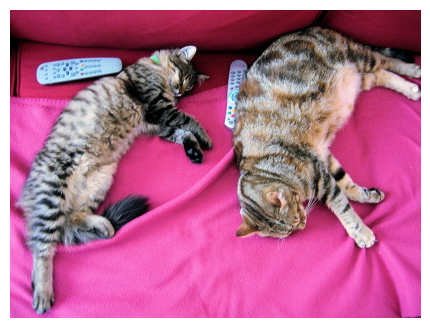

In [6]:


# 이미지 캡셔닝용 공개 체크포인트를 사용한다.
MODEL_NAME = "Salesforce/blip-image-captioning-base"

# Processor는 입력 이미지를 모델 입력 텐서로 변환하고,
# 출력 토큰을 사람이 읽을 수 있는 문자열로 복원하는 데 사용된다.
processor = BlipProcessor.from_pretrained(MODEL_NAME)
model = BlipForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)
model.eval()

# 공개 예시 이미지를 불러온다. 네트워크가 제한되면 로컬 파일로 교체한다.
IMAGE_URL = "http://images.cocodataset.org/val2017/000000039769.jpg"
try:
    with urlopen(IMAGE_URL, timeout=20) as response:
        image = Image.open(response).convert("RGB")
except Exception as exc:
    raise RuntimeError(
        "예시 이미지 다운로드 실패. 로컬 이미지 파일을 Image.open()으로 불러오도록 수정한다."
    ) from exc

plt.figure(figsize=(6, 4))
plt.imshow(image)
plt.axis("off")
plt.show()

## 2. 이미지 설명 생성

`generate()`는 이미지 특징을 바탕으로 토큰을 순차적으로 생성한다. `max_new_tokens`는 새로 생성할 토큰 수의 상한이다. 생성 문장은 모델의 예측이므로 이미지의 모든 사실을 정확히 반영한다고 보장할 수 없다.

In [7]:
# 이미지를 모델이 요구하는 픽셀 텐서로 전처리한다.
inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

# 추론 시에는 기울기 계산을 비활성화해 메모리를 절약한다.
with torch.no_grad():
    output_ids = model.generate(
        **inputs,
        max_new_tokens=40,   # 생성 문장의 최대 길이를 제한한다.
        num_beams=4           # 여러 후보 경로를 탐색하는 빔 서치를 사용한다.
    )

# 토큰 ID를 자연어 문장으로 변환한다.
caption = processor.decode(output_ids[0], skip_special_tokens=True)
print("생성된 이미지 설명:", caption)

생성된 이미지 설명: two cats sleeping on a couch


## 3. 여러 이미지의 설명 비교

설명 생성 결과를 평가할 때는 문장이 자연스러운지만 보지 않는다. 이미지에 실제로 존재하는 객체, 행동, 속성, 장면 관계를 제대로 설명하는지 확인한다.

In [8]:
# 수업 중 서로 다른 로컬 이미지로 image를 바꿔 이 셀을 반복 실행한다.
# 예를 들어 사람, 동물, 음식, 거리 사진을 각각 시험한다.
def generate_caption(input_image, max_new_tokens=40):
    """PIL 이미지 한 장을 받아 BLIP 설명 문장을 반환한다."""
    input_image = input_image.convert("RGB")
    model_inputs = processor(images=input_image, return_tensors="pt")
    model_inputs = {k: v.to(device) for k, v in model_inputs.items()}

    with torch.no_grad():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4
        )

    # skip_special_tokens=True로 모델 내부의 특수 토큰을 제거한다.
    return processor.decode(generated_ids[0], skip_special_tokens=True)

print(generate_caption(image))

two cats sleeping on a couch


## 4. 결과 분석표

이미지별로 다음 항목을 기록한다.

| 항목 | 확인할 내용 |
|---|---|
| 주요 객체 | 핵심 객체를 올바르게 설명했는가? |
| 행동 | 행동이나 상호작용을 정확하게 설명했는가? |
| 속성 | 색상, 수량, 크기 등 세부 속성이 맞는가? |
| 장면 | 배경과 공간적 관계가 적절한가? |
| 환각 | 이미지에 없는 객체나 상황을 만들어 냈는가? |

### 실습 과제
이미지 5장 이상에 대해 설명을 생성하고, 잘못된 설명 사례를 2개 이상 찾아 모델의 한계와 개선 아이디어를 작성한다.

1. 실행 환경
PyTorch 버전 : 2.14.0+cpu
사용 장치     : cpu

2. CIFAR-10 데이터셋 Load
Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})
전체 이미지 수 : 10000

CIFAR-10 클래스
 0 → airplane
 1 → automobile
 2 → bird
 3 → cat
 4 → deer
 5 → dog
 6 → frog
 7 → horse
 8 → ship
 9 → truck

3. 선택된 이미지
 1. Label = cat        | 크기 = (32, 32)
 2. Label = ship       | 크기 = (32, 32)
 3. Label = airplane   | 크기 = (32, 32)
 4. Label = frog       | 크기 = (32, 32)
 5. Label = automobile | 크기 = (32, 32)
 6. Label = truck      | 크기 = (32, 32)
 7. Label = dog        | 크기 = (32, 32)
 8. Label = horse      | 크기 = (32, 32)
 9. Label = deer       | 크기 = (32, 32)
10. Label = bird       | 크기 = (32, 32)

선택 이미지 수: 10

4. BLIP 모델 Load


Loading weights: 100%|██████████| 473/473 [00:00<00:00, 12897.50it/s]


모델 : Salesforce/blip-image-captioning-base
장치 : cpu

5. BLIP 이미지 설명 생성

이미지 01
정답 Label : cat
BLIP Caption: two dogs sitting on a couch looking at each other dogs

이미지 02
정답 Label : ship
BLIP Caption: a boat floating in the water on a foggy day

이미지 03
정답 Label : airplane
BLIP Caption: a poster on a wall in a room

이미지 04
정답 Label : frog
BLIP Caption: a frog sitting on top of a leaf

이미지 05
정답 Label : automobile
BLIP Caption: a white car parked in front of a red wall

이미지 06
정답 Label : truck
BLIP Caption: a white truck is parked on the side of the road

이미지 07
정답 Label : dog
BLIP Caption: a group of people walking down a street

이미지 08
정답 Label : horse
BLIP Caption: a white horse standing on top of a wooden floor

이미지 09
정답 Label : deer
BLIP Caption: an airplane flying over a body of water

이미지 10
정답 Label : bird
BLIP Caption: a group of people standing on top of a lush green field

6. Caption 자동 평가
Image 01 | Label: cat        | 객체 일치: False | two dogs sitting on a couch looking at ea

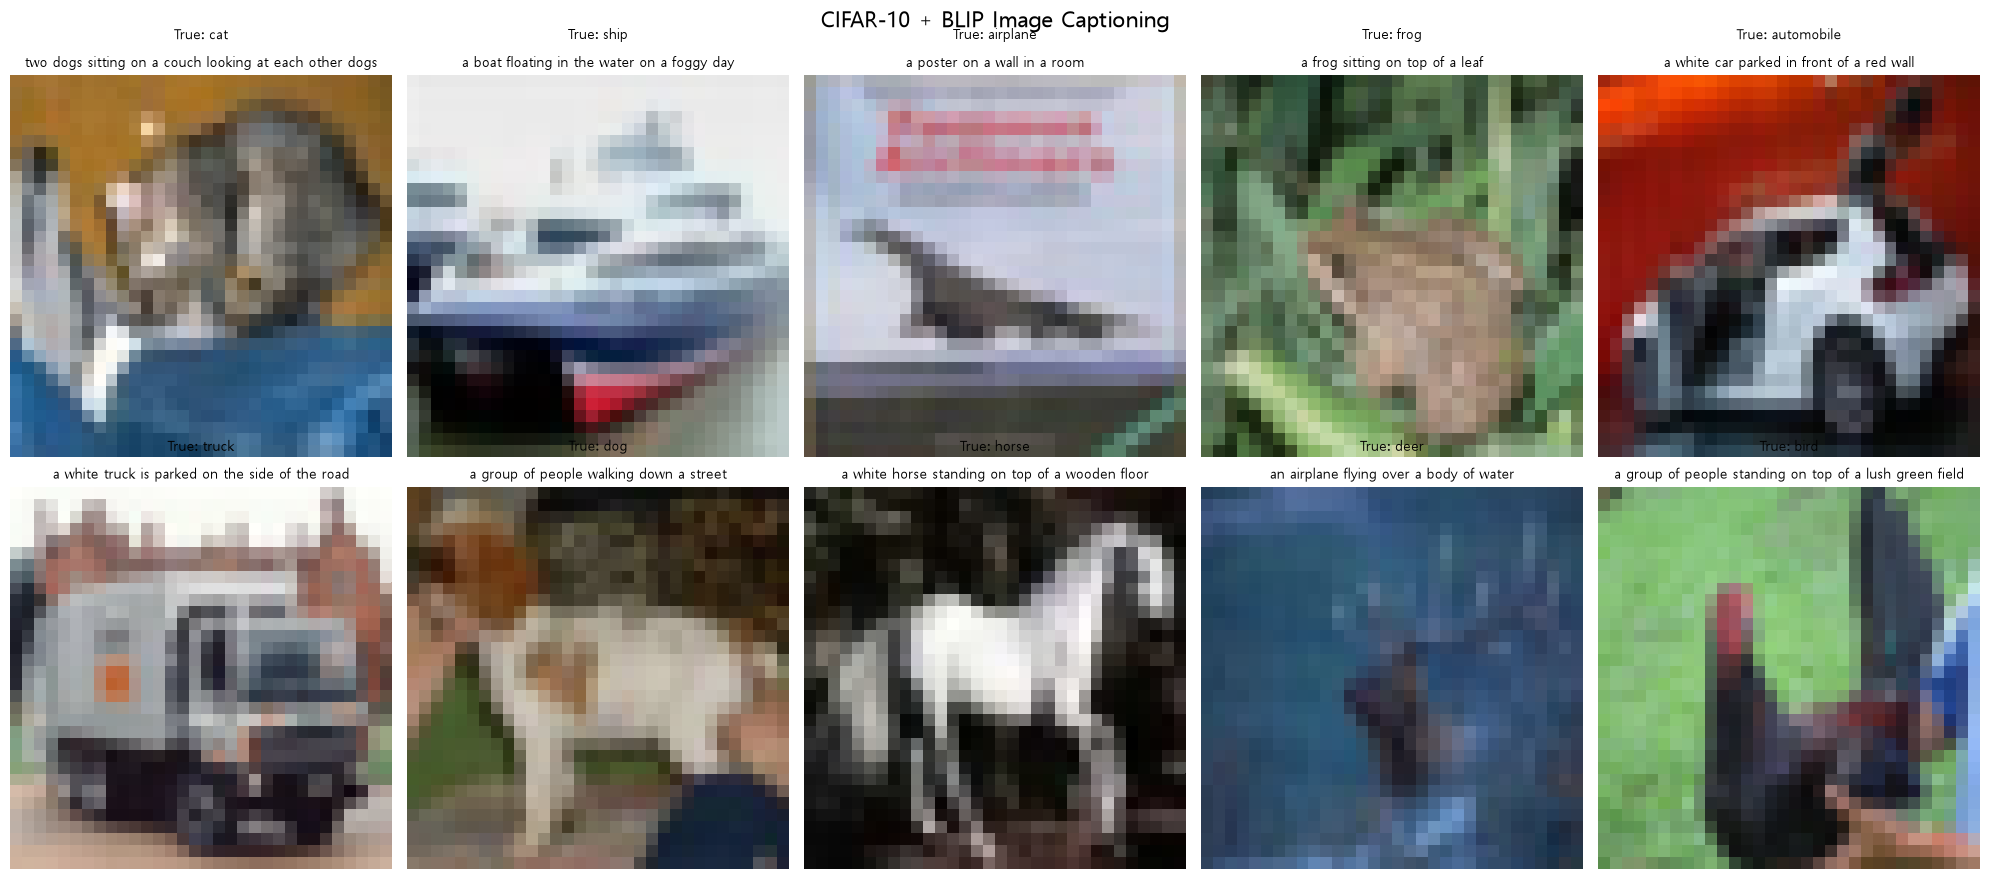


8. 잘못된 설명 후보

오류 후보 1
실제 Label : cat
BLIP 설명  : two dogs sitting on a couch looking at each other dogs

오류 후보 2
실제 Label : airplane
BLIP 설명  : a poster on a wall in a room

오류 후보 3
실제 Label : dog
BLIP 설명  : a group of people walking down a street

오류 후보 4
실제 Label : deer
BLIP 설명  : an airplane flying over a body of water

오류 후보 5
실제 Label : bird
BLIP 설명  : a group of people standing on top of a lush green field


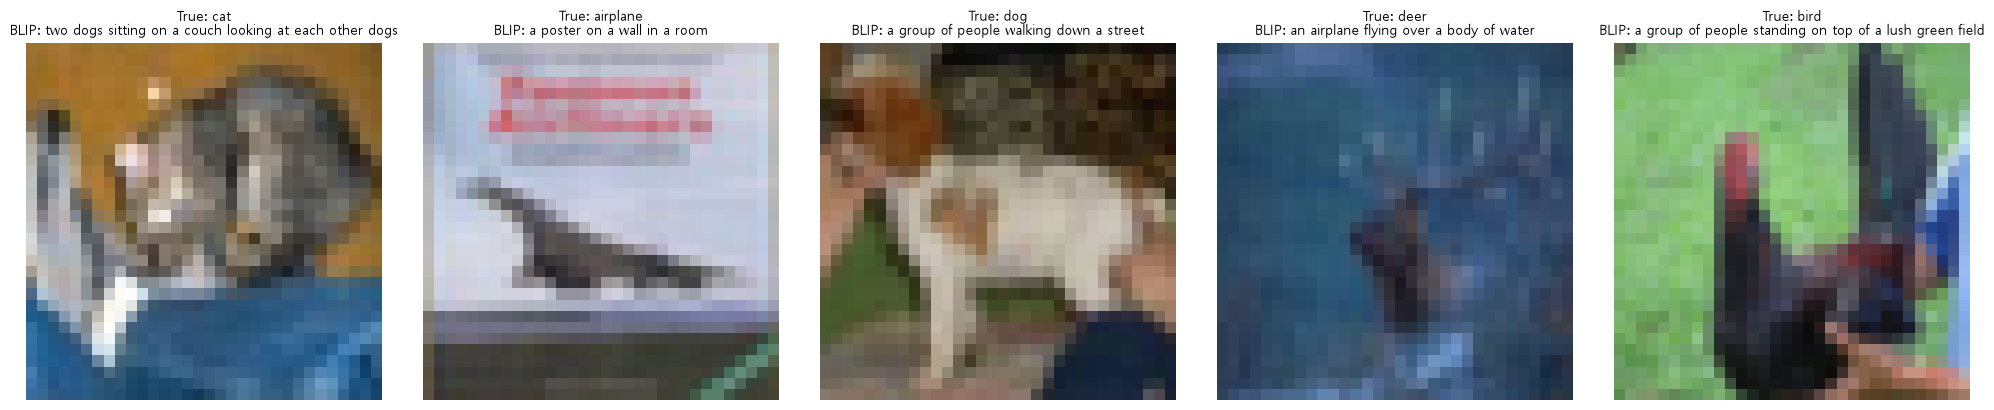


9. 과제 분석 대상

사례 1
실제 Label: cat
BLIP Caption: two dogs sitting on a couch looking at each other dogs

사례 2
실제 Label: airplane
BLIP Caption: a poster on a wall in a room

10. 최종 분석 항목

각 이미지에 대해 다음 항목을 확인한다.

1. 객체가 맞는가?
2. 객체의 개수가 맞는가?
3. 색상이 맞는가?
4. 행동이 맞는가?
5. 배경이 맞는가?
6. 객체 사이의 위치 관계가 맞는가?

잘못된 설명 사례를 최소 2개 선택하여

- 실제 이미지
- 실제 Label
- BLIP이 생성한 Caption
- 무엇이 잘못되었는지
- 오류가 발생한 이유
- 개선 방법

을 작성한다.



In [10]:
# ============================================================
# BLIP Image Captioning + CIFAR-10 실습
# ============================================================
#
# 과제
#
# 1. Hugging Face CIFAR-10에서 이미지를 가져온다.
# 2. 서로 다른 클래스의 이미지 10장을 선택한다.
# 3. BLIP을 이용하여 각 이미지의 설명(Caption)을 생성한다.
# 4. 이미지 / 실제 Label / 생성된 설명을 함께 출력한다.
# 5. 실제 Label이 Caption에 포함되는지 자동으로 확인한다.
# 6. 잘못된 설명 후보를 자동으로 찾는다.
# 7. 잘못된 설명 사례를 최소 2개 이상 출력한다.
# 8. 이미지와 Caption을 시각화한다.
# 9. 모델의 한계와 개선 아이디어를 정리한다.
#
#
# 필요 라이브러리
#
# uv add -U torch transformers datasets pillow matplotlib
#
# ============================================================


# ------------------------------------------------------------
# 1. 라이브러리 가져오기
# ------------------------------------------------------------

import torch
import matplotlib.pyplot as plt

from datasets import load_dataset

from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration
)


# ------------------------------------------------------------
# 2. 실행 장치(Device) 설정
# ------------------------------------------------------------
#
# NVIDIA GPU
#     → CUDA
#
# Apple Silicon
#     → MPS
#
# GPU가 없는 경우
#     → CPU
#
# ------------------------------------------------------------

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)


print("=" * 70)
print("1. 실행 환경")
print("=" * 70)

print("PyTorch 버전 :", torch.__version__)
print("사용 장치     :", device)


# ------------------------------------------------------------
# 3. Hugging Face CIFAR-10 데이터셋 가져오기
# ------------------------------------------------------------
#
# CIFAR-10
#
# - 전체 60,000장
# - Train : 50,000장
# - Test  : 10,000장
#
# 이미지 크기
#
# 32 × 32
#
# 클래스
#
# airplane
# automobile
# bird
# cat
# deer
# dog
# frog
# horse
# ship
# truck
#
# 이번 실습에서는 test 데이터를 사용한다.
#
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. CIFAR-10 데이터셋 Load")
print("=" * 70)


dataset = load_dataset(
    "uoft-cs/cifar10",
    split="test"
)


print(dataset)
print("전체 이미지 수 :", len(dataset))


# ------------------------------------------------------------
# 4. CIFAR-10 클래스 이름 가져오기
# ------------------------------------------------------------

class_names = dataset.features["label"].names


print("\nCIFAR-10 클래스")

for index, class_name in enumerate(class_names):

    print(
        f"{index:2d} → {class_name}"
    )


# ------------------------------------------------------------
# 5. 실습에 사용할 클래스
# ------------------------------------------------------------
#
# 과제에서는 이미지가 5장 이상이면 된다.
#
# 여기서는 결과를 조금 더 다양하게 관찰하기 위해
# 10개 클래스에서 각각 한 장씩 사용한다.
#
# 총 10장
#
# ------------------------------------------------------------

TARGET_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# ------------------------------------------------------------
# 6. 각 클래스에서 이미지 한 장씩 선택
# ------------------------------------------------------------

selected_images = []


for dataset_index, sample in enumerate(dataset):

    # 숫자 Label
    label_index = sample["label"]

    # 숫자 Label → 실제 클래스 이름
    label_name = class_names[label_index]


    # --------------------------------------------------------
    # 현재 클래스가 실습 대상인지 확인한다.
    # --------------------------------------------------------

    if label_name not in TARGET_CLASSES:
        continue


    # --------------------------------------------------------
    # 이미 해당 클래스 이미지를 가져왔는지 확인한다.
    # --------------------------------------------------------

    already_selected = any(

        item["label"] == label_name

        for item in selected_images
    )


    if already_selected:
        continue


    # --------------------------------------------------------
    # CIFAR-10 이미지 가져오기
    # --------------------------------------------------------
    #
    # CIFAR-10 Hugging Face 데이터셋의 이미지 컬럼은
    #
    # "img"
    #
    # 이다.
    #
    # --------------------------------------------------------

    image = sample["img"].convert("RGB")


    # --------------------------------------------------------
    # 선택한 이미지 정보 저장
    # --------------------------------------------------------

    selected_images.append({

        "dataset_index":
            dataset_index,

        "label":
            label_name,

        "image":
            image

    })


    # --------------------------------------------------------
    # 10개 클래스를 모두 선택했다면 종료
    # --------------------------------------------------------

    if len(selected_images) == len(TARGET_CLASSES):
        break


print("\n" + "=" * 70)
print("3. 선택된 이미지")
print("=" * 70)


for i, item in enumerate(
    selected_images,
    start=1
):

    print(
        f"{i:2d}. "
        f"Label = {item['label']:10s} | "
        f"크기 = {item['image'].size}"
    )


print(
    "\n선택 이미지 수:",
    len(selected_images)
)


# ============================================================
# 7. BLIP Image Captioning 모델 준비
# ============================================================
#
# CLIP과 BLIP의 차이
#
#
# CLIP
# ------------------------------------------------------------
#
# Image
#    ↓
# Image Encoder
#    ↓
# Image Embedding
#
#                 ← Similarity →
#
# Text Embedding
#    ↑
# Text Encoder
#    ↑
# Text
#
#
# CLIP은 이미지와 텍스트의
# "유사도 비교"에 적합하다.
#
#
# BLIP
# ------------------------------------------------------------
#
# Image
#    ↓
# Vision Encoder
#    ↓
# Image Feature
#    ↓
# Language Decoder
#    ↓
# Caption 생성
#
#
# BLIP은 이미지에 대한
# 자연어 설명을 생성할 수 있다.
#
# ============================================================

MODEL_NAME = "Salesforce/blip-image-captioning-base"


print("\n" + "=" * 70)
print("4. BLIP 모델 Load")
print("=" * 70)


# ------------------------------------------------------------
# BLIP Processor
# ------------------------------------------------------------
#
# 이미지를 BLIP이 처리할 수 있는 형태로 변환한다.
#
# PIL Image
#
#      ↓
#
# Resize / Normalize
#
#      ↓
#
# pixel_values
#
# ------------------------------------------------------------

processor = BlipProcessor.from_pretrained(
    MODEL_NAME
)


# ------------------------------------------------------------
# BLIP Captioning Model
# ------------------------------------------------------------

model = (
    BlipForConditionalGeneration
    .from_pretrained(MODEL_NAME)
    .to(device)
)


# 추론 모드
model.eval()


print("모델 :", MODEL_NAME)
print("장치 :", device)


# ============================================================
# 8. 이미지 설명 생성 함수
# ============================================================

def generate_caption(image):

    """
    PIL 이미지를 입력받아
    BLIP으로 이미지 설명을 생성한다.
    """


    # --------------------------------------------------------
    # 1. PIL Image → BLIP 입력 Tensor
    # --------------------------------------------------------

    inputs = processor(
        images=image,
        return_tensors="pt"
    )


    # --------------------------------------------------------
    # 2. Tensor를 모델과 동일한 장치로 이동
    # --------------------------------------------------------

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }


    # --------------------------------------------------------
    # 3. Caption 생성
    # --------------------------------------------------------
    #
    # 현재는 학습이 아니라 추론이므로
    # Gradient를 계산하지 않는다.
    #
    # max_new_tokens
    #
    # 생성할 Caption의 최대 토큰 수를 제한한다.
    #
    # num_beams
    #
    # Beam Search를 사용하여
    # 여러 후보 문장을 탐색한다.
    #
    # --------------------------------------------------------

    with torch.no_grad():

        generated_ids = model.generate(

            **inputs,

            max_new_tokens=30,

            num_beams=5
        )


    # --------------------------------------------------------
    # 4. Token ID → 문자열
    # --------------------------------------------------------

    caption = processor.decode(

        generated_ids[0],

        skip_special_tokens=True
    )


    return caption.strip()


# ============================================================
# 9. 10개 이미지 Caption 생성
# ============================================================

print("\n" + "=" * 70)
print("5. BLIP 이미지 설명 생성")
print("=" * 70)


results = []


for index, item in enumerate(
    selected_images,
    start=1
):


    # --------------------------------------------------------
    # BLIP Caption 생성
    # --------------------------------------------------------

    caption = generate_caption(
        item["image"]
    )


    # --------------------------------------------------------
    # 결과 저장
    # --------------------------------------------------------

    result = {

        "number":
            index,

        "dataset_index":
            item["dataset_index"],

        "image":
            item["image"],

        "label":
            item["label"],

        "caption":
            caption
    }


    results.append(result)


    print(
        f"\n이미지 {index:02d}"
    )

    print(
        "정답 Label :",
        item["label"]
    )

    print(
        "BLIP Caption:",
        caption
    )


# ============================================================
# 10. Caption 평가를 위한 클래스 동의어 정의
# ============================================================
#
# 단순히
#
# label in caption
#
# 으로 검사하면 문제가 있다.
#
# 예를 들어 CIFAR Label은
#
# automobile
#
# 이지만 BLIP은
#
# "a car on the road"
#
# 라고 생성할 가능성이 있다.
#
# car는 automobile과 의미적으로 같은 객체이므로
# 정답으로 인정해야 한다.
#
# 따라서 클래스별 동의어를 정의한다.
#
# ============================================================

LABEL_KEYWORDS = {

    "airplane": [
        "airplane",
        "plane",
        "aircraft",
        "jet"
    ],

    "automobile": [
        "automobile",
        "car",
        "vehicle"
    ],

    "bird": [
        "bird"
    ],

    "cat": [
        "cat",
        "kitten"
    ],

    "deer": [
        "deer"
    ],

    "dog": [
        "dog",
        "puppy"
    ],

    "frog": [
        "frog",
        "toad"
    ],

    "horse": [
        "horse",
        "pony"
    ],

    "ship": [
        "ship",
        "boat",
        "vessel"
    ],

    "truck": [
        "truck",
        "lorry"
    ]
}


# ============================================================
# 11. Caption이 정답 객체를 포함하는지 확인
# ============================================================

def contains_correct_object(
    label,
    caption
):

    # 대소문자 차이를 제거한다.
    caption_lower = caption.lower()


    # 해당 Label의 동의어 목록
    keywords = LABEL_KEYWORDS[label]


    # Caption에 동의어가 하나라도 있으면 True
    return any(keyword in caption_lower  for keyword in keywords)


# ============================================================
# 12. 생성된 Caption 자동 평가
# ============================================================

print("\n" + "=" * 70)
print("6. Caption 자동 평가")
print("=" * 70)


wrong_cases = []


for result in results:


    # --------------------------------------------------------
    # Caption이 실제 객체를 올바르게 언급하는지 검사
    # --------------------------------------------------------

    object_match = contains_correct_object(

        result["label"],

        result["caption"]
    )


    # 결과 저장
    result["object_match"] = object_match


    # --------------------------------------------------------
    # 잘못된 설명 후보 저장
    # --------------------------------------------------------

    if not object_match:

        wrong_cases.append(
            result
        )


    print(

        f"Image {result['number']:02d} | "

        f"Label: {result['label']:10s} | "

        f"객체 일치: {object_match} | "

        f"{result['caption']}"

    )


# ============================================================
# 13. 자동 평가 결과
# ============================================================

correct_count = sum(

    result["object_match"]

    for result in results
)


wrong_count = (
    len(results)
    -
    correct_count
)


accuracy = (
    correct_count
    /
    len(results)
    *
    100
)


print("\n" + "=" * 70)
print("7. Caption 평가 결과")
print("=" * 70)


print(
    "전체 이미지 :",
    len(results)
)

print(
    "객체 일치   :",
    correct_count
)

print(
    "불일치 후보 :",
    wrong_count
)

print(
    f"객체 일치율 : {accuracy:.2f}%"
)


# ============================================================
# 14. 이미지 + Label + Caption 시각화
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 9)
)


axes = axes.flatten()


for ax, result in zip(
    axes,
    results
):


    # --------------------------------------------------------
    # CIFAR-10 이미지 출력
    # --------------------------------------------------------

    ax.imshow(
        result["image"]
    )


    # --------------------------------------------------------
    # 제목
    #
    # True
    # → CIFAR 실제 Label
    #
    # Caption
    # → BLIP이 생성한 설명
    # --------------------------------------------------------

    ax.set_title(

        f"True: {result['label']}\n\n"

        f"{result['caption']}",

        fontsize=10
    )


    ax.axis("off")


plt.suptitle(

    "CIFAR-10 + BLIP Image Captioning",

    fontsize=16
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. 잘못된 설명 후보 출력
# ============================================================
#
# 여기서 매우 중요한 점:
#
# 자동 평가는 완벽한 Caption 평가가 아니다.
#
# CIFAR Label과 관련된 단어가 Caption에 존재하는지를
# 확인하는 간단한 Rule-based 평가이다.
#
# 따라서 최종적으로 사람이 이미지를 직접 확인해야 한다.
#
# ============================================================

print("\n" + "=" * 70)
print("8. 잘못된 설명 후보")
print("=" * 70)


if len(wrong_cases) == 0:

    print(
        "자동 평가에서 객체가 완전히 틀린 Caption을 찾지 못했습니다."
    )

    print(
        "하지만 세부 속성, 개수, 배경, 행동 등은 "
        "사람이 직접 확인해야 합니다."
    )


else:

    for index, result in enumerate(
        wrong_cases,
        start=1
    ):

        print(
            f"\n오류 후보 {index}"
        )

        print(
            "실제 Label :",
            result["label"]
        )

        print(
            "BLIP 설명  :",
            result["caption"]
        )


# ============================================================
# 16. 잘못된 설명 이미지 시각화
# ============================================================

if len(wrong_cases) > 0:


    # 최대 5개까지만 출력
    display_wrong_cases = wrong_cases[:5]


    fig, axes = plt.subplots(

        1,

        len(display_wrong_cases),

        figsize=(
            4 * len(display_wrong_cases),
            4
        )
    )


    # 오류가 한 개인 경우 처리
    if len(display_wrong_cases) == 1:
        axes = [axes]


    for ax, result in zip(
        axes,
        display_wrong_cases
    ):

        ax.imshow(
            result["image"]
        )

        ax.set_title(

            f"True: {result['label']}\n"

            f"BLIP: {result['caption']}",

            fontsize=10
        )

        ax.axis("off")


    plt.tight_layout()

    plt.show()


# ============================================================
# 17. 최소 2개의 분석 대상 선택
# ============================================================
#
# 자동으로 틀린 Caption이 2개 이상 발견되었다면
# 앞에서부터 2개를 분석 대상으로 선택한다.
#
# 하지만 자동 오류가 2개 미만일 수도 있다.
#
# 그 경우에는 모든 Caption을 사람이 직접 보고
#
# - 객체
# - 색상
# - 개수
# - 행동
# - 배경
# - 위치 관계
#
# 중 잘못 설명된 사례를 추가로 선택해야 한다.
#
# ============================================================

analysis_cases = wrong_cases[:2]


print("\n" + "=" * 70)
print("9. 과제 분석 대상")
print("=" * 70)


if len(analysis_cases) >= 2:

    for index, result in enumerate(
        analysis_cases,
        start=1
    ):

        print(
            f"\n사례 {index}"
        )

        print(
            "실제 Label:",
            result["label"]
        )

        print(
            "BLIP Caption:",
            result["caption"]
        )


else:

    print(
        "자동으로 발견된 객체 오분류가 2개 미만입니다."
    )

    print(
        "위의 10개 이미지를 직접 확인하여 "
        "세부 설명이 잘못된 사례를 추가로 선택하세요."
    )


# ============================================================
# 18. 최종 과제 안내
# ============================================================

print("\n" + "=" * 70)
print("10. 최종 분석 항목")
print("=" * 70)


print("""
각 이미지에 대해 다음 항목을 확인한다.

1. 객체가 맞는가?
2. 객체의 개수가 맞는가?
3. 색상이 맞는가?
4. 행동이 맞는가?
5. 배경이 맞는가?
6. 객체 사이의 위치 관계가 맞는가?

잘못된 설명 사례를 최소 2개 선택하여

- 실제 이미지
- 실제 Label
- BLIP이 생성한 Caption
- 무엇이 잘못되었는지
- 오류가 발생한 이유
- 개선 방법

을 작성한다.
""")

이번 과제에서는 **CLIP이 아니라 BLIP**을 사용해야 한다. CLIP은 이미지와 텍스트의 유사도 계산에 적합하고, 이미지에 대한 자연어 설명을 직접 생성하려면 Image Captioning 모델인 `Salesforce/blip-image-captioning-base`를 사용하는 것이 적절하다. 해당 모델은 Hugging Face에서 unconditional/conditional image captioning을 지원한다. [Hugging Face](https://huggingface.co/Salesforce/blip-image-captioning-base?utm_source=chatgpt.com)

CIFAR-10은 `img`, `label` 컬럼을 제공하며 이미지는 **32×32**이다. 총 10개 클래스가 있으므로 이번에는 서로 다른 클래스의 이미지를 사용해 설명 생성 성능을 관찰한다. [Hugging Face](https://huggingface.co/datasets/uoft-cs/cifar10?utm_source=chatgpt.com)



## 실행 결과를 어떻게 평가하는가

여기서 `CIFAR-10 Label`은 **Caption의 정답 문장**이 아니다. 예를 들어 CIFAR-10의 정답이 `dog`라고 해서 정답 Caption이 반드시 `"a dog"`인 것은 아니다.

이미지가 강아지라면 BLIP은 다음처럼 더 구체적으로 생성할 수도 있다.

```text
True Label : dog

BLIP:
"a brown dog standing in the grass"
```

이 경우 객체 수준에서는 올바른 Caption이다.

반대로 다음과 같다면 명확한 오류이다.

```text
True Label : dog

BLIP:
"a brown horse standing in a field"
```

따라서 코드에서는 먼저 **객체 수준의 명백한 오류를 자동으로 찾아주고**, 최종적인 사실성 평가는 사람이 이미지를 보고 확인하도록 구성했다.

---

# 잘못된 설명 사례 분석 방법

실행 결과에서 실제 오류가 다음처럼 나왔다고 **가정**해 보자. 아래 문장은 실제 실행 결과가 아니라 작성 방법을 보여주기 위한 예시이다.

| 구분 | 사례 1 | 사례 2 |
|---|---|---|
| CIFAR Label | cat | truck |
| BLIP Caption 예 | `a dog sitting...` | `a car driving...` |
| 오류 | 고양이를 강아지로 인식 | 트럭을 승용차로 인식 |
| 오류 유형 | 객체 오인식 | 유사 객체 혼동 |
| 주요 원인 | 저해상도 | 세부 특징 부족 |

실제 보고서에는 **본인 코드에서 출력된 Caption을 그대로 사용**해야 한다.

## 모델의 한계

이 실습에서는 특히 **입력 이미지의 해상도**를 고려해야 한다. CIFAR-10은 32×32 컬러 이미지이다. [Hugging Face](https://huggingface.co/datasets/uoft-cs/cifar10?utm_source=chatgpt.com)

```text
CIFAR-10
32 × 32
   ↓
매우 작은 이미지
   ↓
BLIP Processor
   ↓
모델 입력 크기로 확대
   ↓
BLIP
   ↓
Caption
```

이미지를 확대한다고 해서 원래 없던 세부 정보가 새로 생기는 것은 아니다.

예를 들어,

```text
32 × 32
   ↓
224 × 224로 확대
```

하더라도 **원본의 시각 정보 자체는 여전히 32×32 수준**이다. 따라서 고양이와 강아지, 자동차와 트럭처럼 시각적으로 유사한 객체를 혼동할 가능성이 있다.

두 번째 한계는 **Hallucination**이다. BLIP은 이미지에서 확인할 수 있는 사실만 복사하는 것이 아니라 언어 모델을 통해 자연스러운 Caption을 생성한다. 따라서 이미지에 명확하게 나타나지 않은 색상, 장소, 행동, 배경 등을 그럴듯하게 생성할 수 있다.

세 번째는 **세부 속성 인식의 한계**이다. 객체 자체는 맞더라도 다음 내용은 틀릴 수 있다.

```text
객체     → dog       ✓

색상     → brown     ?
개수     → two       ?
행동     → running   ?
장소     → park      ?
위치관계 → next to   ?
```

즉, `dog`라는 핵심 객체를 맞췄다고 Caption 전체가 사실적으로 정확한 것은 아니다.

---

# 개선 아이디어

개선 방법은 다음 세 가지 방향으로 정리하면 좋다.

첫째, **더 높은 해상도의 이미지 데이터셋을 사용한다.** CIFAR-10은 32×32이므로 Captioning 자체에는 상당히 불리하다. 원본 해상도가 높은 이미지에서는 객체의 모양, 색상, 행동, 배경 등에 대한 시각 정보가 더 많이 제공된다.

둘째, **더 강력한 Vision-Language Model과 비교한다.** 이번 실습의 `Salesforce/blip-image-captioning-base`는 BLIP의 기본 Captioning 모델이다. Hugging Face 모델 카드는 이 모델을 conditional 및 unconditional image captioning에 사용할 수 있다고 명시한다. [Hugging Face](https://huggingface.co/Salesforce/blip-image-captioning-base?utm_source=chatgpt.com)

셋째, **Caption 생성 후 검증 단계를 추가한다.**

예를 들면 이전에 학습한 CLIP과 연결할 수 있다.

```text
CIFAR Image
     ↓
    BLIP
     ↓
Caption 생성
     ↓
"a brown dog running"
     │
     │
     ▼
    CLIP
     │
     ▼
Image ↔ Caption
Similarity
     ↓
낮은 유사도?
     ↓
검토 대상으로 표시
```

단, CLIP 유사도 역시 사실 검증 점수는 아니므로 최종 사실성을 보장하는 장치는 아니다.

---

## 과제  답안

> **실험 방법**  
> Hugging Face의 CIFAR-10 test 데이터에서 10개 클래스의 이미지를 각각 한 장씩 선택하였다. 각 이미지를 `Salesforce/blip-image-captioning-base`에 입력하여 자연어 Caption을 생성하였다. 생성 결과는 CIFAR-10의 실제 클래스 Label과 비교하고, 이미지도 직접 확인하여 객체, 색상, 개수, 행동, 배경 등의 사실성을 평가하였다.
>
> **잘못된 설명 분석**  
> 생성된 Caption 중 실제 객체와 다른 객체를 설명하거나, 객체는 올바르게 인식했지만 색상·행동·배경 등의 세부 내용이 실제 이미지와 일치하지 않는 사례를 최소 2개 선정하였다. CIFAR-10 이미지가 32×32의 저해상도라는 점이 세부적인 시각 정보 파악을 어렵게 만드는 주요 원인 중 하나라고 판단하였다.
>
> **모델의 한계**  
> BLIP은 이미지의 내용을 이해하여 자연어를 생성하지만 Caption의 모든 내용이 실제 이미지의 사실과 일치한다고 보장할 수 없다. 특히 저해상도 이미지에서는 유사한 객체를 혼동할 수 있으며, 객체의 색상, 개수, 행동, 위치 관계 및 배경에 대한 설명이 부정확할 수 있다. 또한 이미지에서 명확하게 확인되지 않는 내용을 자연스럽게 생성하는 Hallucination이 발생할 수 있다.
>
> **개선 아이디어**  
> 더 높은 해상도의 이미지를 사용하고, 더 강력한 Vision-Language Model과 결과를 비교할 수 있다. 또한 Caption을 생성한 뒤 객체 탐지나 CLIP과 같은 별도의 모델을 이용하여 생성된 설명과 이미지의 일치도를 추가로 검사하는 검증 단계를 구성할 수 있다.

[Hugging Face CIFAR-10 데이터셋](https://huggingface.co/datasets/uoft-cs/cifar10?utm_source=chatgpt.com)  
[Hugging Face BLIP Image Captioning 모델](https://huggingface.co/Salesforce/blip-image-captioning-base?utm_source=chatgpt.com)